# Setup

## Import modules

In [53]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from PIL import Image
import torch
from datetime import datetime

# Import pipeline modules
from scoring import score_image
from selection import select
from metrics import MetricsTracker
from generation.UnconditionalGenerator import UnconditionalGenerator
from generation.LatentSurvivalGenerator import LatentSurvivalGenerator
from utils import save_image, set_seed
import shutil

# Config
OUTPUT_DIR = Path("outputs")

# Experiment parameters
NUM_PROMPTS = 30
NUM_TRIALS = 1
ROUNDS = 4        # r
BATCH_SIZE = 4    # B
SEED = 42

# Chosen strategies
SELECTION_STRATEGY = "argmax"

# Baseline scoring rubric (example)
# CLIP_RUBRIC = {"type": "clip", "text": "A photorealistic portrait of a dog", "weight": 1.0}
# BRIGHTNESS_RUBRIC = {"type": "brightness", "weight": 1.0}

set_seed(SEED)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load diffusion model

In [4]:
import torch
from diffusers import StableDiffusion3Pipeline

pipe = StableDiffusion3Pipeline.from_pretrained(
    "stabilityai/stable-diffusion-3-medium-diffusers",
    text_encoder_3=None,
    tokenizer_3=None,
    torch_dtype=torch.float16,
    # device_map="balanced",
)
pipe.enable_sequential_cpu_offload()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

## Load dataset

In [5]:
# Load dev and test datasets 
dev_dataset = pd.read_csv("data/dev_dataset.csv")
test_dataset = pd.read_csv("data/test_dataset.csv")

# Run simulation

In [55]:
START_IDX = 0
DATASET = dev_dataset[START_IDX : START_IDX + NUM_PROMPTS]

metrics = MetricsTracker()
policy = LatentSurvivalGenerator(pipe, alpha=0.1, gamma=1.0)

 # based on date and time
RUN_DIR = OUTPUT_DIR / datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
RUN_DIR.mkdir(parents=True, exist_ok=True)

IMAGES_DIR = RUN_DIR / "images"
METRICS_CSV = RUN_DIR / "metrics.csv"

for trial in range(NUM_TRIALS):
    print("="*100)
    print(f"BEGINNING TRIAL {trial}")
    print("="*100)

    trial_id = f"trial{trial}"

    for item_idx, item in enumerate(tqdm(DATASET.to_dict(orient="records"), desc="prompts")):
        prompt_id = item["prompt_id"]
        prompt = item["prompt"]

        # Compile rubric
        rubric = {}
        for key, value in item.items():
            if key.startswith("rubric_"):
                rubric[key.replace("rubric_", "")] = value

        # Initialize policy
        policy.initialize(prompt=prompt, batch_size=BATCH_SIZE)

        print(f"\nItem {item_idx}:")
        print(f"\tprompt_id={prompt_id}")
        print(f"\tprompt=\"{prompt}\"")
        print(f"\trubric={rubric}")
        print()

        prompt_outdir = IMAGES_DIR / prompt_id / trial_id

        for round in range(ROUNDS):
            first_round = (round == 0)

            print(f"\tRound {round}")
            round_outdir = prompt_outdir / f"round{round}"
            round_outdir.mkdir(parents=True, exist_ok=True)
            
            # Score and record metrics for each image in the batch
            user_scores = []

            # If not the first round, include the previous winner as the first image in the batch
            if not first_round:
                image_path = round_outdir / f"image{0}.png"
                previous_winner = metrics.clone_previous_winner(
                    prompt_id,
                    trial_id,
                    round, # the current round
                    image_path # the new image path
                )

                user_scores.append(previous_winner["user_score"])
                # clone the previous winner image to the new destination
                shutil.copy(previous_winner["image_path"], image_path)

            
            # Generate the necessary number of images using our method
            new_images: list[Image.Image] = policy.generate(
                sampling_parameters={
                    "num_inference_steps": 1,
                    "guidance_scale": 7.5,
                    "width": 512,
                    "height": 512,
                    # "generator": torch.Generator(device="cuda").manual_seed(SEED), # this leads to different trials having the same images
                }
            )

            for image_idx, image in zip(range(0 if first_round else 1, BATCH_SIZE), new_images):
                image_path = round_outdir / f"image{image_idx}.png"
                
                user_score = score_image(image, rubric)
                user_scores.append(user_score)
                
                metrics.log(
                    prompt_id,
                    trial_id,
                    round,
                    image_idx,
                    image_path,
                    user_score,
                    image,
                    extra_info={
                        "prompt": prompt,
                    }
                )
                save_image(image, image_path)

            # Select favorite (index)
            chosen_image_idx = select(user_scores, strategy=SELECTION_STRATEGY)
            metrics.mark_chosen(
                prompt_id,
                trial_id,
                round,
                chosen_image_idx,
            )

            # Update policy
            policy.update(winner_index=chosen_image_idx)

            print(f"\t\tImages saved to {round_outdir}")
            print(f"\t\tScores: {user_scores}")
            print(f"\t\tChosen index (using {SELECTION_STRATEGY}): {chosen_image_idx}")
            
            
        # Repeatedly save metrics per item, for safety
        metrics.save(str(METRICS_CSV)) # autoprints


BEGINNING TRIAL 0


prompts:   0%|          | 0/30 [00:00<?, ?it/s]


Item 0:
	prompt_id=001369-0084
	prompt="greek or roman sculpture in marble of a philosopher holding a skull, in a museum background, hyperrealistic photograph in the style of bernini, golden hour"
	rubric={'type': 'ImageReward', 'prompt': 'greek or roman sculpture in marble of a philosopher holding a skull, in a museum background, hyperrealistic photograph in the style of bernini, golden hour'}

	Round 0
num_new_images 4


  0%|          | 0/1 [00:00<?, ?it/s]

self.batch_latents.shape torch.Size([4, 16, 64, 64])
self.last_winner_latent.shape torch.Size([16, 64, 64])
self.running_latent.shape torch.Size([16, 64, 64])
		Images saved to outputs/2025-11-14_08-06-09/images/001369-0084/trial0/round0
		Scores: [-2.284130573272705, -2.27604341506958, -2.2834079265594482, -2.2495386600494385]
		Chosen index (using argmax): 3
	Round 1
num_new_images 3
noise.shape torch.Size([3, 16, 64, 64])
new_latents.shape torch.Size([3, 16, 64, 64])
self.batch_latents.shape torch.Size([4, 16, 64, 64])


...

self.batch_latents.shape torch.Size([4, 16, 64, 64])
self.last_winner_latent.shape torch.Size([16, 64, 64])
self.running_latent.shape torch.Size([16, 64, 64])
		Images saved to outputs/2025-11-14_08-06-09/images/001369-0084/trial0/round1
		Scores: [-2.2495386600494385, -2.2810304164886475, -2.282212018966675, -2.2821831703186035]
		Chosen index (using argmax): 0
	Round 2
num_new_images 3
noise.shape torch.Size([3, 16, 64, 64])
new_latents.shape torch.Size([3, 16, 64, 64])
self.batch_latents.shape torch.Size([4, 16, 64, 64])


  0%|          | 0/1 [00:00<?, ?it/s]

self.batch_latents.shape torch.Size([4, 16, 64, 64])
self.last_winner_latent.shape torch.Size([16, 64, 64])
self.running_latent.shape torch.Size([16, 64, 64])
		Images saved to outputs/2025-11-14_08-06-09/images/001369-0084/trial0/round2
		Scores: [-2.2495386600494385, -2.2829573154449463, -2.2818920612335205, -2.282515287399292]
		Chosen index (using argmax): 0
	Round 3
num_new_images 3
noise.shape torch.Size([3, 16, 64, 64])
new_latents.shape torch.Size([3, 16, 64, 64])
self.batch_latents.shape torch.Size([4, 16, 64, 64])


  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
metrics.to_dataframe()

In [34]:
new_latents = pipe.prepare_latents(
    batch_size=1,
    num_channels_latents=pipe.vae.config.latent_channels,
    height=512,
    width=512,
    dtype=pipe.vae.dtype,
    device="cpu",
    generator=torch.Generator(),
)

In [35]:
new_latents.shape

torch.Size([1, 16, 64, 64])

  0%|          | 0/20 [00:00<?, ?it/s]

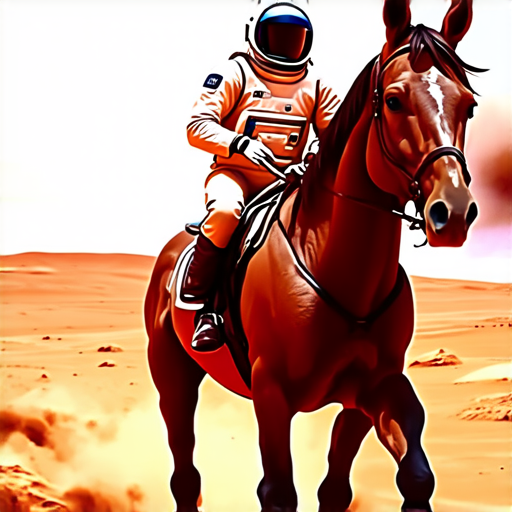

In [36]:
# Generate with these new latents
pipe(
    prompt="A photo of an astronaut riding a horse on mars",
    latents=new_latents,
    num_images_per_prompt=1,
    width=512,
    height=512,
    num_inference_steps=20,
    guidance_scale=7.5,
).images[0]